In [1]:
import sys; print(sys.executable)    

/home/cjen/mySageMaker/ML/anomaly_detection/.venv/bin/python


In [2]:
try:
    import boto3
except ImportError:
    import sys
    !{sys.executable} -m pip install -q boto3                                                
    import boto3

In [3]:
import botocore
import sagemaker
import sys
from time import gmtime, strftime
import logging

logging.getLogger("sagemaker.config").setLevel(logging.WARNING)

# Initialize the SageMaker session
sagemaker_session = sagemaker.Session()

# PASTE YOUR ROLE ARN HERE
role = 'arn:aws:iam::493644444178:role/SageMakerLocalExecutionRole'
print("Default Sagemaker Studio IAM role: " + role)

# Test: Try to get the default S3 bucket (verifies AWS connectivity)
try:
    bucket = sagemaker_session.default_bucket()
    print(f"Success! Connected to bucket: {bucket}")
except Exception as e:
    print(f"Error: {e}")

# S3 bucket name only (no path)
bucket = "sagemaker-us-west-2-493644444178"
lab_prefix = "anomaly-detection-lab-083609365668-fe9d93f0"

print("default-bucket: " + bucket)

prefix = f"{lab_prefix}/sagemaker/rcf-benchmarks"

# S3 bucket where the original data is downloaded and stored.
downloaded_data_bucket = bucket
downloaded_data_prefix = lab_prefix
data_filename = "nyc_taxi.csv"

def check_bucket_permission(bucket):
    permission = False
    try:
        boto3.Session().client("s3").head_bucket(Bucket=bucket)
    except botocore.exceptions.ParamValidationError as e:
        print(
            "Hey! You either forgot to specify your S3 bucket"
            " or you gave your bucket an invalid name!"
        )
    except botocore.exceptions.ClientError as e:
        if e.response["Error"]["Code"] == "403":
            print(f"Hey! You don't have permission to access the bucket, {bucket}.")
        elif e.response["Error"]["Code"] == "404":
            print(f"Hey! Your bucket, {bucket}, doesn't exist!")
        else:
            raise
    else:
        permission = True
    return permission

if check_bucket_permission(bucket):
    print(f"Training input/output will be stored in: s3://{bucket}/{prefix}")
if check_bucket_permission(downloaded_data_bucket):
    print(f"Downloaded training data will be read from s3://{downloaded_data_bucket}/{downloaded_data_prefix}")

sagemaker.config INFO - Not applying SDK defaults from location: /etc/xdg/sagemaker/config.yaml
sagemaker.config INFO - Not applying SDK defaults from location: /home/cjen/.config/sagemaker/config.yaml
Default Sagemaker Studio IAM role: arn:aws:iam::493644444178:role/SageMakerLocalExecutionRole
Success! Connected to bucket: sagemaker-us-west-2-493644444178
default-bucket: sagemaker-us-west-2-493644444178
Training input/output will be stored in: s3://sagemaker-us-west-2-493644444178/anomaly-detection-lab-083609365668-fe9d93f0/sagemaker/rcf-benchmarks
Downloaded training data will be read from s3://sagemaker-us-west-2-493644444178/anomaly-detection-lab-083609365668-fe9d93f0


### Step 1: Load and Explore the Data - Download pedestrian count data from S3 and visualize it.

In [4]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams["figure.dpi"] = 100

# Download data from S3
s3 = boto3.client("s3")
s3.download_file(
    downloaded_data_bucket,
    f"{downloaded_data_prefix}/{data_filename}",
    data_filename,
)

# Load into DataFrame
data = pd.read_csv(data_filename, delimiter=",")
print(data.shape)
data.head()

(10320, 2)


,timestamp,value
0,2014-07-01 00:00:00,10844
1,2014-07-01 00:30:00,8127
2,2014-07-01 01:00:00,6210
3,2014-07-01 01:30:00,4656
4,2014-07-01 02:00:00,3820


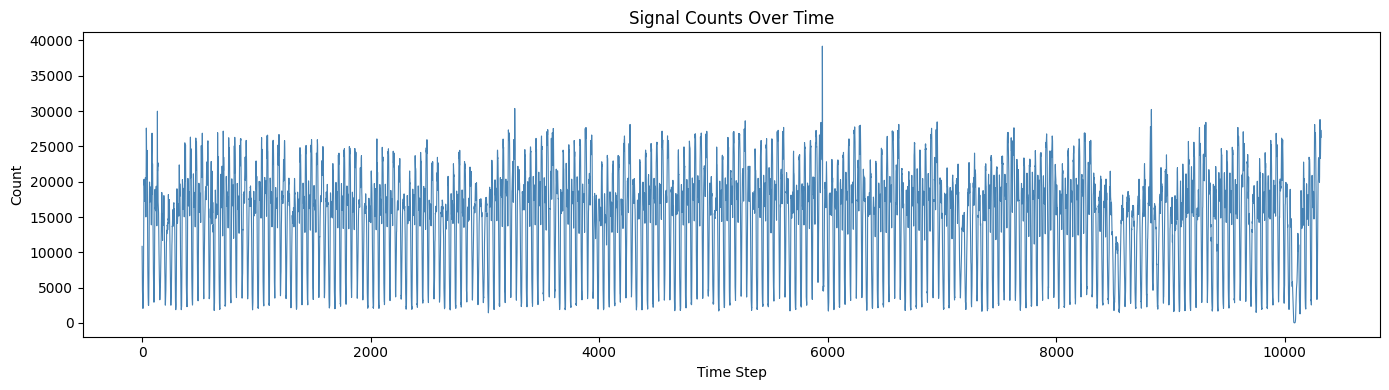

Total samples: 10320
Min: 8, Max: 39197, Mean: 15137.57


In [5]:
# Plot raw pedestrian counts
pedestrian_counts = data.iloc[:, 1].values

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(pedestrian_counts, color="steelblue", linewidth=0.8)
ax.set_title("Signal Counts Over Time")
ax.set_xlabel("Time Step")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

print(f"Total samples: {len(pedestrian_counts)}")
print(f"Min: {pedestrian_counts.min()}, Max: {pedestrian_counts.max()}, Mean: {pedestrian_counts.mean():.2f}")

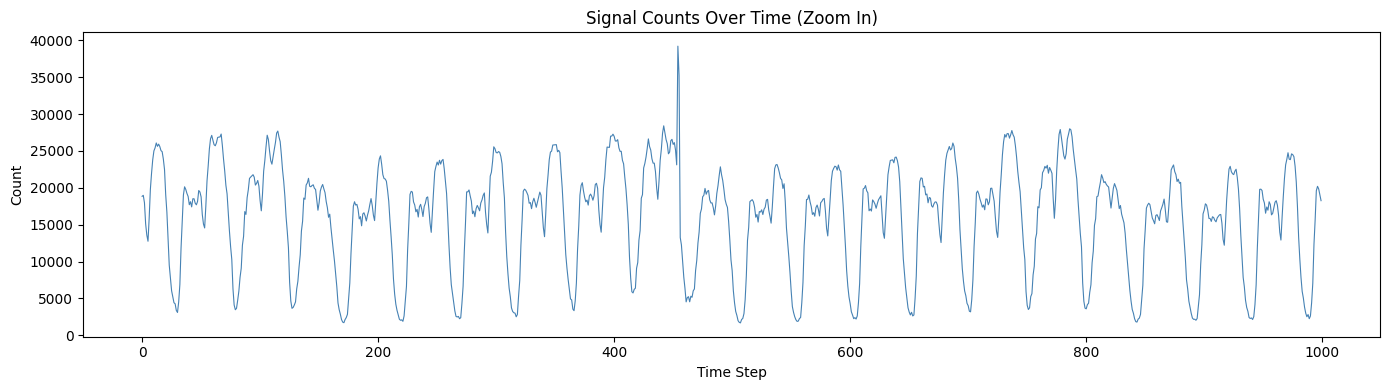

Total samples: 10320
Min: 8, Max: 39197, Mean: 15137.57


In [6]:
pedestrian_counts_zoom = data.iloc[5500:6500, 1].values

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(pedestrian_counts_zoom, color="steelblue", linewidth=0.8)
ax.set_title("Signal Counts Over Time (Zoom In)")
ax.set_xlabel("Time Step")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

print(f"Total samples: {len(pedestrian_counts)}")
print(f"Min: {pedestrian_counts.min()}, Max: {pedestrian_counts.max()}, Mean: {pedestrian_counts.mean():.2f}")

In [7]:
data.describe()

,value
count,10320.000000
mean,15137.569380
std,6939.495808
min,8.000000
25%,10262.000000
50%,16778.000000
75%,19838.750000
max,39197.000000


### Step 2: Prepare and Upload Training Data - RCF expects data in RecordIO-protobuf format. We use the SageMaker SDK helper to convert and upload.

In [8]:
from sagemaker import RandomCutForest
from sagemaker.amazon.common import RecordSerializer

# Reshape to (n_samples, n_features)
rcf_data = pedestrian_counts.reshape(-1, 1).astype("float32")

# Upload training data in RecordIO-protobuf format
training_data_channel = sagemaker.Session().upload_data(
    path=data_filename,
    bucket=bucket,
    key_prefix=f"{prefix}/train",
)
print(f"Training data uploaded to: {training_data_channel}")

Training data uploaded to: s3://sagemaker-us-west-2-493644444178/anomaly-detection-lab-083609365668-fe9d93f0/sagemaker/rcf-benchmarks/train/nyc_taxi.csv


### Step 3: Train the RCF Model - Train SageMaker's built-in Random Cut Forest algorithm.

In [9]:
rcf = RandomCutForest(
    role=role,
    instance_count=1,
    instance_type="ml.m5.large",  # changed from "local" to avoid Docker Desktop ECR conflict
    data_location=f"s3://{bucket}/{prefix}/train/",
    output_path=f"s3://{bucket}/{prefix}/output",
    num_samples_per_tree=512,
    num_trees=50,
    sagemaker_session=sagemaker.Session(),  # changed from LocalSession
)

In [10]:
rcf.fit(rcf.record_set(rcf_data))

INFO:sagemaker.image_uris:Same images used for training and inference. Defaulting to image scope: inference.
INFO:sagemaker.image_uris:Ignoring unnecessary instance type: None.
INFO:sagemaker:Creating training-job with name: randomcutforest-2026-03-20-03-57-48-169


2026-03-20 03:57:49 Starting - Starting the training job...
2026-03-20 03:58:03 Starting - Preparing the instances for training...
2026-03-20 03:58:26 Downloading - Downloading input data...
2026-03-20 03:59:06 Downloading - Downloading the training image.........
2026-03-20 04:00:52 Training - Training image download completed. Training in progress..Docker entrypoint called with argument(s): train
Running default environment configuration script
/opt/amazon/lib/python3.8/site-packages/mxnet/model.py:97: SyntaxWarning: "is" with a literal. Did you mean "=="?
  if num_device is 1 and 'dist' not in kvstore:
/opt/amazon/lib/python3.8/site-packages/scipy/optimize/_shgo.py:495: SyntaxWarning: "is" with a literal. Did you mean "=="?
  if cons['type'] is 'ineq':
/opt/amazon/lib/python3.8/site-packages/scipy/optimize/_shgo.py:743: SyntaxWarning: "is not" with a literal. Did you mean "!="?
  if len(self.X_min) is not 0:
[03/20/2026 04:00:58 INFO 139904855267136] Reading default configuration fr

### Step 4: Deploy Endpoint and Run Inference

In [11]:
from sagemaker.serializers import CSVSerializer
from sagemaker.deserializers import JSONDeserializer

rcf_predictor = rcf.deploy(
    initial_instance_count=1,
    instance_type="ml.m5.large",
    serializer=CSVSerializer(),
    deserializer=JSONDeserializer(),
)
print(f"Endpoint name: {rcf_predictor.endpoint_name}")

INFO:sagemaker.image_uris:Same images used for training and inference. Defaulting to image scope: inference.
INFO:sagemaker.image_uris:Ignoring unnecessary instance type: None.
INFO:sagemaker:Creating model with name: randomcutforest-2026-03-20-04-03-47-207
INFO:sagemaker:Creating endpoint-config with name randomcutforest-2026-03-20-04-03-47-207
INFO:sagemaker:Creating endpoint with name randomcutforest-2026-03-20-04-03-47-207


--------!Endpoint name: randomcutforest-2026-03-20-04-03-47-207


In [12]:
# Run inference in batches to avoid payload size limits
def get_anomaly_scores(predictor, data, batch_size=500):
    scores = []
    for i in range(0, len(data), batch_size):
        batch = data[i : i + batch_size]
        result = predictor.predict(batch)
        scores += [r["score"] for r in result["scores"]]
    return np.array(scores)

anomaly_scores = get_anomaly_scores(rcf_predictor, rcf_data)
print(f"Computed {len(anomaly_scores)} anomaly scores")
print(f"Score stats — min: {anomaly_scores.min():.2f}, max: {anomaly_scores.max():.2f}, mean: {anomaly_scores.mean():.2f}")

Computed 10320 anomaly scores
Score stats — min: 0.65, max: 4.66, mean: 0.89


### Step 5: Visualize Anomalies - Flag points whose score exceeds 3 standard deviations above the mean.

Threshold: 1.69
Anomalies detected: 231 at indices: [   37    38    87   134   527   661   710  1094  1098  1198  3031  3206
  3207  3208  3212  3213  3214  3215  3261  3262  3263  3496  3543  3544
  3548  3549  3550  3551  3590  3591  3592  3598  3599  3600  3879  3880
  3884  3885  3886  3887  3935  3936  4222  4269  4270  4271  4272  4550
  4551  4599  4838  4839  4843  4844  4893  4894  4895  4934  4935  4942
  4943  4944  5175  5179  5222  5223  5224  5227  5228  5229  5230  5270
  5271  5277  5278  5279  5280  5558  5559  5560  5564  5565  5566  5567
  5606  5607  5614  5615  5616  5897  5898  5899  5900  5903  5929  5941
  5942  5943  5944  5949  5954  5955  6231  6232  6233  6234  6235  6236
  6237  6238  6239  6277  6278  6279  6284  6285  6286  6287  6288  6522
  6566  6567  6571  6572  6573  6574  6614  6615  6622  6623  6624  6903
  6908  6909  6910  6911  6949  6950  6957  6958  6959  6960  7351  7574
  7575  7576  7579  7580  7629  7630  7631  7632  7916  7917  7966  8247

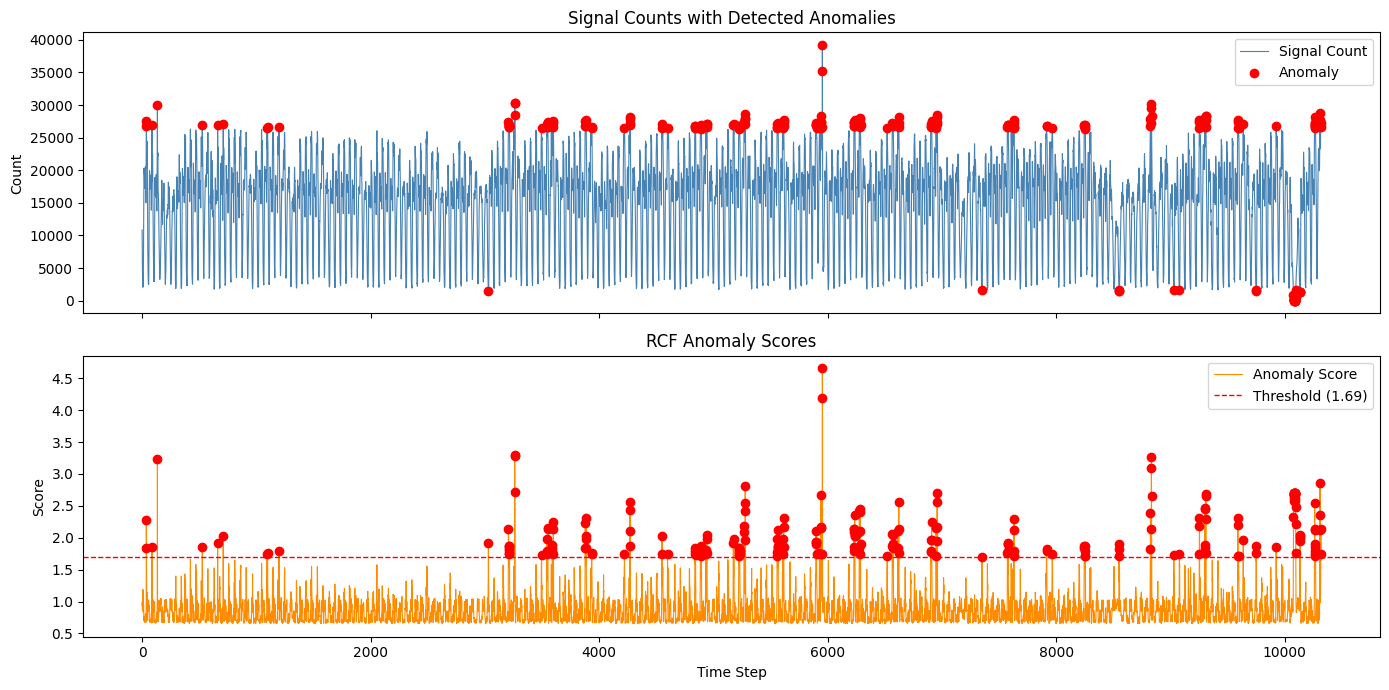

In [13]:
score_mean = anomaly_scores.mean()
score_std = anomaly_scores.std()
anomaly_threshold = score_mean + 3 * score_std

anomalies = np.where(anomaly_scores > anomaly_threshold)[0]
print(f"Threshold: {anomaly_threshold:.2f}")
print(f"Anomalies detected: {len(anomalies)} at indices: {anomalies}")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

# Raw counts with anomalies highlighted
ax1.plot(pedestrian_counts, color="steelblue", linewidth=0.8, label="Signal Count")
ax1.scatter(anomalies, pedestrian_counts[anomalies], color="red", zorder=5, label="Anomaly")
ax1.set_title("Signal Counts with Detected Anomalies")
ax1.set_ylabel("Count")
ax1.legend()

# Anomaly scores
ax2.plot(anomaly_scores, color="darkorange", linewidth=0.8, label="Anomaly Score")
ax2.axhline(anomaly_threshold, color="red", linestyle="--", linewidth=1, label=f"Threshold ({anomaly_threshold:.2f})")
ax2.scatter(anomalies, anomaly_scores[anomalies], color="red", zorder=5)
ax2.set_title("RCF Anomaly Scores")
ax2.set_xlabel("Time Step")
ax2.set_ylabel("Score")
ax2.legend()

plt.tight_layout()
plt.show()

### Step 6: Cleanup - Delete the endpoint to avoid ongoing charges.

In [14]:
rcf_predictor.delete_endpoint()
print("Endpoint deleted.")

INFO:sagemaker:Deleting endpoint configuration with name: randomcutforest-2026-03-20-04-03-47-207
INFO:sagemaker:Deleting endpoint with name: randomcutforest-2026-03-20-04-03-47-207


Endpoint deleted.
